# Ablation D: Component Ablation of HierarchicalSpecGNN

Tests the contribution of each architectural component by removing one at a time.
All variants share the same **transductive molecular network** (MASST cosine edges over
train+val+test nodes -> Leiden communities on every connected component -> per-community
Maximum Weight Spanning Tree -> 4 MCN community features computed directly for all
nodes), features, and train/val/test split -- the identical pipeline used by
`spectral_classifier-hierarchical.ipynb` and `ablation_a_masst_sweep.ipynb`.

| Variant | What is removed |
|---------|----------------|
| **Full model** | — (baseline) |
| **w/o JK connections** | Jump-knowledge skip: only last layer output used |
| **w/o MCN features** | 4 community features removed; model uses 340-dim spectral only |
| **w/o DropEdge** | Edge dropout disabled (`drop_edge_p=0`) |
| **w/o LayerNorm** | LayerNorm removed from GNN blocks and JK layer |


## 1. Imports

In [1]:
import os, csv, gc
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_edge
import warnings
warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')


C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 2. Configuration

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
mgf_path          = 'NIST/NIST_GC_EI_MAX_LIBRARY.mgf'
nist_classes_path = 'NIST/nist_classes.csv'
nist_dir          = 'C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST'
masst_tsv_path    = f'{nist_dir}/results_t50_e20.tsv'

use_4class = True
four_classes = [
    'Benzene and substituted derivatives',
    'Carboxylic acids and derivatives',
    'Fatty Acyls',
    'Organooxygen compounds',
]

leiden_seed     = 42
min_leiden_size = 10

random_state = 42; test_size = 0.20; val_size = 0.10

# Model hyperparameters (fixed across all variants)
hidden = 128; num_layers = 2; num_heads = 4; dropout = 0.3; drop_edge_p = 0.1
epochs = 200; lr = 1e-3; patience = 20; w_sc = 0.3; w_cl = 0.7

print(f'MASST TSV: {os.path.exists(masst_tsv_path)}')
print(f'lr={lr}  hidden={hidden}  layers={num_layers}  heads={num_heads}')


MASST TSV: True
lr=0.001  hidden=128  layers=2  heads=4


## 3. Data Loading

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == 'BEGIN IONS': inside, meta, peaks = True, {}, []; continue
            if line == 'END IONS':
                if inside:
                    entries.append({'meta': meta.copy(),
                        'peaks': np.array(peaks, dtype=float) if peaks
                                 else np.empty((0,2), dtype=float)})
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if '=' in line: k, v = line.split('=',1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries

def read_nist_classes_csv(path):
    label_map = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for row in csv.DictReader(f):
            sid = int(row['file'].strip())
            sk = row['Superklass'].strip(); k = row['klass'].strip()
            label_map[sid] = {
                'superclass': None if sk == 'null' else sk,
                'klass': None if (k == 'null' or k.startswith('subklass:')) else k,
            }
    return label_map

print('Loading MGF ...')
mgf_entries    = parse_mgf_file(mgf_path)
nist_label_map = read_nist_classes_csv(nist_classes_path)
dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'],
                    'superclass': lbl['superclass'], 'klass': lbl['klass']})
if use_4class:
    dataset = [r for r in dataset if r['klass'] in four_classes]
print(f'Dataset: {len(dataset):,} spectra')


Loading MGF ...
Dataset: 84,692 spectra


## 4. Split & Features

In [4]:
# Split
all_idx = list(range(len(dataset))); all_labels = [r['klass'] for r in dataset]
lc = Counter(all_labels)
keep = [i for i in all_idx if lc[all_labels[i]] >= 2]
kl   = [all_labels[i] for i in keep]
tr_val, te_idx = train_test_split(keep, test_size=test_size, stratify=kl,
                                   random_state=random_state)
tr_idx, va_idx = train_test_split(tr_val,
    test_size=val_size/(1-test_size),
    stratify=[all_labels[i] for i in tr_val], random_state=random_state)
train_scan_ids = {dataset[i]['scan_id'] for i in tr_idx}
val_scan_ids   = {dataset[i]['scan_id'] for i in va_idx}
test_scan_ids  = {dataset[i]['scan_id'] for i in te_idx}
node_order_indices = sorted(r['scan_id'] for r in dataset)
scan_to_pos    = {sid: i for i, sid in enumerate(node_order_indices)}
scan_to_ds_idx = {r['scan_id']: i for i, r in enumerate(dataset)}
n_nodes        = len(node_order_indices)

# Spectral features (340-dim)
def peaks_to_features(peaks, top_k=20):
    n_out = top_k * 17
    if peaks is None or len(peaks) == 0: return np.zeros(n_out, dtype=np.float32)
    p = peaks.astype(np.float32)
    p = p[np.argsort(p[:,1])[::-1][:top_k]]
    if len(p) < top_k:
        p = np.vstack([p, np.zeros((top_k-len(p), 2), dtype=np.float32)])
    mz, inten = p[:,0], p[:,1]; inten = inten / max(inten.max(), 1e-6)
    wl  = np.logspace(-1, 3, num=8, dtype=np.float32)
    ang = (2*np.pi*mz[:,None]) / wl[None,:]
    enc = np.empty((top_k, 16), dtype=np.float32)
    enc[:,0::2] = np.sin(ang); enc[:,1::2] = np.cos(ang)
    return np.concatenate([enc, inten[:,None]], axis=1).flatten()

raw_x = np.stack([peaks_to_features(dataset[scan_to_ds_idx[sid]]['peaks'])
                  for sid in node_order_indices], axis=0).astype(np.float32)
tr_rows  = np.array([scan_to_pos[s] for s in train_scan_ids])
feat_mean = raw_x[tr_rows].mean(0, keepdims=True)
feat_std  = raw_x[tr_rows].std(0,  keepdims=True).clip(min=1e-6)
x_spec    = ((raw_x - feat_mean) / feat_std).astype(np.float32)
print(f'train={len(train_scan_ids):,}  val={len(val_scan_ids):,}  test={len(test_scan_ids):,}')
print(f'x_spec (spectral only): {x_spec.shape}')


train=59,283  val=8,470  test=16,939
x_spec (spectral only): (84692, 340)


## 5. Labels & Masks

In [5]:
le_sc = LabelEncoder().fit(sorted(set(r['superclass'] for r in dataset)))
le_cl = LabelEncoder().fit(sorted(set(r['klass']      for r in dataset)))
n_sc  = len(le_sc.classes_); n_cl = len(le_cl.classes_)
y_sc_dev = torch.tensor(
    [int(le_sc.transform([dataset[scan_to_ds_idx[sid]]['superclass']])[0])
     for sid in node_order_indices], dtype=torch.long).to(device)
y_cl_dev = torch.tensor(
    [int(le_cl.transform([dataset[scan_to_ds_idx[sid]]['klass']])[0])
     for sid in node_order_indices], dtype=torch.long).to(device)

def make_mask(scan_ids):
    m = torch.zeros(n_nodes, dtype=torch.bool)
    for i, sid in enumerate(node_order_indices):
        if sid in scan_ids: m[i] = True
    return m
train_mask = make_mask(train_scan_ids)
val_mask   = make_mask(val_scan_ids)
test_mask  = make_mask(test_scan_ids)
train_mask_dev = train_mask.to(device)
val_mask_dev   = val_mask.to(device)
test_mask_dev  = test_mask.to(device)

sc_to_cl_mask = torch.zeros(n_sc, n_cl, dtype=torch.bool)
for r in dataset:
    sc_to_cl_mask[
        int(le_sc.transform([r['superclass']])[0]),
        int(le_cl.transform([r['klass']])[0])] = True
sc_to_cl_mask_dev = sc_to_cl_mask.to(device)

def make_wts(y, mask, n):
    c = np.bincount(y[mask].cpu().numpy(), minlength=n).astype(float)
    w = 1.0 / c.clip(min=1)
    return torch.tensor((w / w.sum() * n).astype(np.float32)).to(device)
sc_wts = make_wts(y_sc_dev, train_mask_dev, n_sc)
cl_wts = make_wts(y_cl_dev, train_mask_dev, n_cl)
print(f'n_sc={n_sc}  n_cl={n_cl}')


n_sc=4  n_cl=4


## 6. Build Transductive Molecular Network + MCN

Rebuilds the **exact transductive pipeline** verified in
`spectral_classifier-hierarchical.ipynb` and `ablation_a_masst_sweep.ipynb`
(`build_transductive_mcn`, ported unchanged):

1. Load MASST cosine-similarity edges over **all** nodes (train + val + test), indexed
   by global node position -- only spectral similarity drives the graph, labels are
   never touched.
2. Leiden community detection on every connected component (isolated -> singleton
   community, size < `min_leiden_size` -> one community, else Leiden).
3. Maximum Weight Spanning Tree (MWST) within every community.
4. 4 MCN community features (`log_size`, `degree_cent`, `dist_centroid`,
   `singleton_flag`) computed **directly for all nodes** from this single
   transductive community assignment -- no separate train-only graph, no
   nearest-centroid extrapolation for val/test.
5. Bidirectional MWST edge tensors used **identically for training and evaluation** --
   message passing spans all nodes, the loss stays masked to training nodes only, so
   this remains leakage-free transductive learning.


In [6]:
def build_transductive_mcn(masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
                            min_leiden_size=10, leiden_seed=42):
    """Build the transductive MCN pipeline for one MASST TSV file.

    Identical algorithm to spectral_classifier-hierarchical.ipynb / ablation_a_masst_sweep.ipynb:
      1. Read MASST pairwise cosine-similarity edges, keep edges where both endpoints
         are in the dataset, index nodes by GLOBAL position (transductive: all nodes,
         not just train) -- only spectral similarity drives the graph, labels are
         never touched.
      2. Leiden community detection on every connected component.
      3. Maximum Weight Spanning Tree (MWST) within every community -- keeps the
         highest-cosine edges as the GNN graph.
      4. 4 MCN community features for ALL nodes: log_size, degree_cent,
         dist_to_centroid, singleton_flag.
      5. Bidirectional edge tensors -- the SAME graph is returned for both training
         and evaluation (transductive).

    Returns
    -------
    x_aug_dev      : (n_nodes, 344) tensor, spectral + community features, on device
    mcn_edge_index : (2, E) bidirectional edge index, on device
    mcn_edge_attr  : (E, 1) cosine-similarity edge weights, on device
    info           : dict of diagnostics (n_edges, n_communities, n_mst_edges,
                      n_singletons, mean_purity)
    """
    all_scan_ids = set(scan_to_pos)

    # 1. Build the network over ALL nodes
    pairs = []
    for chunk in pd.read_csv(
            masst_tsv_path, sep='\t',
            usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
            dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
            chunksize=500_000):
        chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
        chunk = chunk[chunk['scan_1'].isin(all_scan_ids) & chunk['scan_2'].isin(all_scan_ids)]
        if len(chunk) == 0:
            continue
        u = chunk['scan_1'].map(scan_to_pos).to_numpy()
        v = chunk['scan_2'].map(scan_to_pos).to_numpy()
        pairs.append(np.column_stack([np.minimum(u, v), np.maximum(u, v),
                                      chunk['dot_product_shifted'].to_numpy()]))

    allp = np.concatenate(pairs, axis=0) if pairs else np.zeros((0, 3), dtype=np.float32)
    edf  = pd.DataFrame({'u': allp[:, 0].astype(np.int64),
                         'v': allp[:, 1].astype(np.int64),
                         'cosine_score': allp[:, 2].astype(np.float32)})
    edf  = edf.groupby(['u', 'v'], as_index=False)['cosine_score'].max()

    G = nx.from_pandas_edgelist(edf, 'u', 'v', edge_attr='cosine_score')
    G.add_nodes_from(range(n_nodes))   # ensure isolated nodes are included

    # 2. Leiden community detection on every connected component
    all_components = sorted(nx.connected_components(G), key=len, reverse=True)
    mcn_pos_to_comm = {}
    next_comm_id    = 0
    for comp_nodes in all_components:
        size = len(comp_nodes)
        if size == 1:
            node = list(comp_nodes)[0]
            mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        elif size < min_leiden_size:
            for node in comp_nodes:
                mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        else:
            comp_nodes_sorted = sorted(comp_nodes)
            local_remap       = {old: new for new, old in enumerate(comp_nodes_sorted)}
            subgraph          = G.subgraph(comp_nodes_sorted)

            ig_comp = ig.Graph(n=size, directed=False)
            ig_comp.add_edges([(local_remap[u], local_remap[v]) for u, v in subgraph.edges()])
            ig_comp.es['weight'] = [subgraph.edges[u, v]['cosine_score'] for u, v in subgraph.edges()]

            part = leidenalg.find_partition(
                ig_comp, leidenalg.ModularityVertexPartition,
                weights='weight', seed=leiden_seed)

            for local_i, mcn_pos in enumerate(comp_nodes_sorted):
                mcn_pos_to_comm[mcn_pos] = next_comm_id + int(part.membership[local_i])
            next_comm_id += len(part)
    n_communities = next_comm_id
    singleton_nodes = {node for node in G.nodes() if G.degree(node) == 0}

    # 3. Maximum Weight Spanning Tree per community
    comm_to_nodes = defaultdict(list)
    for mcn_pos, comm_id in mcn_pos_to_comm.items():
        comm_to_nodes[comm_id].append(mcn_pos)

    mst_edges = []
    for cid in range(n_communities):
        members = comm_to_nodes[cid]
        if len(members) <= 1:
            continue
        local_idx       = {mcn_pos: i for i, mcn_pos in enumerate(members)}
        n_c             = len(members)
        rows, cols, wts = [], [], []
        for u in members:
            for v in G.neighbors(u):
                if mcn_pos_to_comm.get(v) == cid and v in local_idx:
                    rows.append(local_idx[u])
                    cols.append(local_idx[v])
                    wts.append(G.edges[u, v]['cosine_score'])
        if not rows:
            continue
        mat = _csr_mat((np.array(wts, dtype=np.float32), (rows, cols)), shape=(n_c, n_c))
        neg = mat.copy(); neg.data *= -1
        mst = _mst_func(neg).tocoo(); mst.data *= -1
        for r, c, w in zip(mst.row, mst.col, mst.data):
            mst_edges.append((members[r], members[c], float(w)))

    # 4. Bidirectional edge tensors -- SAME graph used for train and eval
    if mst_edges:
        src_list = [u for u, v, w in mst_edges]
        dst_list = [v for u, v, w in mst_edges]
        wts_list = [w for u, v, w in mst_edges]
        src_bi = src_list + dst_list
        dst_bi = dst_list + src_list
        wts_bi = wts_list + wts_list
        mcn_edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)
        mcn_edge_attr  = torch.tensor(wts_bi, dtype=torch.float32).unsqueeze(1)
    else:
        mcn_edge_index = torch.zeros((2, 0), dtype=torch.long)
        mcn_edge_attr  = torch.zeros((0, 1), dtype=torch.float32)

    # 5. Community features for ALL nodes (transductive)
    node_comm_id   = np.array([mcn_pos_to_comm[i] for i in range(n_nodes)], dtype=np.int64)
    comm_sizes_arr = np.bincount(node_comm_id, minlength=n_communities)

    comm_centroids = np.zeros((n_communities, x_spec.shape[1]), dtype=np.float32)
    np.add.at(comm_centroids, node_comm_id, x_spec)
    comm_centroids /= np.maximum(comm_sizes_arr[:, None], 1)

    f_log_size = np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)

    degree_arr    = np.array([G.degree(i) for i in range(n_nodes)], dtype=np.float32)
    size_m1       = np.maximum(comm_sizes_arr[node_comm_id] - 1, 1).astype(np.float32)
    f_degree_cent = (degree_arr / size_m1).clip(0, 1)

    diffs       = x_spec - comm_centroids[node_comm_id]
    f_dist_cent = np.linalg.norm(diffs, axis=1).astype(np.float32)

    f_singleton = np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],
                           dtype=np.float32)

    comm_features = np.stack([f_log_size, f_degree_cent, f_dist_cent, f_singleton], axis=1).astype(np.float32)
    x_aug = np.concatenate([x_spec, comm_features], axis=1).astype(np.float32)

    # Community class purity -- diagnostic only, never used by the model
    sid_to_klass = {r['scan_id']: r['klass'] for r in dataset}
    comm_members = defaultdict(list)
    for pos in range(n_nodes):
        comm_members[node_comm_id[pos]].append(pos)
    purities = []
    for cid in range(n_communities):
        klasses = [sid_to_klass[node_order_indices[p]]
                   for p in comm_members.get(cid, [])
                   if node_order_indices[p] in sid_to_klass]
        if not klasses:
            continue
        dominant_n = Counter(klasses).most_common(1)[0][1]
        purities.append(dominant_n / len(klasses))
    mean_purity = float(np.mean(purities)) if purities else float('nan')

    info = {
        'n_edges':       G.number_of_edges(),
        'n_communities': n_communities,
        'n_mst_edges':   len(mst_edges),
        'n_singletons':  len(singleton_nodes),
        'mean_purity':   mean_purity,
    }

    x_aug_dev      = torch.tensor(x_aug, dtype=torch.float32).to(device)
    mcn_edge_index = mcn_edge_index.to(device)
    mcn_edge_attr  = mcn_edge_attr.to(device)

    return x_aug_dev, mcn_edge_index, mcn_edge_attr, info


print('Building transductive molecular network + MCN ...')
x_aug_dev, mcn_ei_dev, mcn_ea_dev, mcn_info = build_transductive_mcn(
    masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
    min_leiden_size=min_leiden_size, leiden_seed=leiden_seed,
)
x_spec_dev = torch.tensor(x_spec, dtype=torch.float32).to(device)  # 340-dim (no MCN), for 'w/o MCN features'

# Same graph used for training AND eval (transductive); loss stays masked to train_mask
ei_tr, ea_tr = mcn_ei_dev, mcn_ea_dev
ei_ev, ea_ev = mcn_ei_dev, mcn_ea_dev

print(f'Network : {mcn_info["n_edges"]:,} edges  {mcn_info["n_communities"]:,} communities  '
      f'{mcn_info["n_mst_edges"]:,} MWST edges  {mcn_info["n_singletons"]:,} singletons  '
      f'mean_purity={mcn_info["mean_purity"]:.3f}')
print(f'x_aug={x_aug_dev.shape}  x_spec={x_spec_dev.shape}  ei_tr={ei_tr.shape[1]:,}')


Building transductive molecular network + MCN ...
Network : 888,192 edges  9,087 communities  75,600 MWST edges  357 singletons  mean_purity=0.954
x_aug=torch.Size([84692, 344])  x_spec=torch.Size([84692, 340])  ei_tr=151,200


## 7. Model Variants

`HierarchicalSpecGNN` is parameterised so that each ablation variant
can be instantiated by flipping a flag — no separate class needed.

In [7]:
class SpecGNNBlock(nn.Module):
    """GAT block with optional DropEdge and optional LayerNorm."""
    def __init__(self, in_ch, out_ch, num_heads=4, dropout=0.3,
                 drop_edge_p=0.1, use_layernorm=True):
        super().__init__()
        assert out_ch % num_heads == 0
        self.drop_edge_p  = drop_edge_p
        self.conv = GATConv(in_ch, out_ch//num_heads, heads=num_heads,
                            concat=True, dropout=dropout,
                            edge_dim=1, add_self_loops=False)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch) if use_layernorm else nn.Identity()
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, ei, ea, training=False):
        if training and self.drop_edge_p > 0:
            ei, mask = dropout_edge(ei, p=self.drop_edge_p,
                                    force_undirected=True, training=True)
            ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_attr=ea))) + self.res(x))


class HierarchicalSpecGNN(nn.Module):
    def __init__(self, feat_dim=344, hidden=128, num_layers=2, num_heads=4,
                 n_superclass=4, n_class=4, dropout=0.3, drop_edge_p=0.1,
                 use_jk=True, use_layernorm=True):
        super().__init__()
        self.use_jk = use_jk
        self.norm_in = nn.LayerNorm(feat_dim) if use_layernorm else nn.Identity()
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden) if use_layernorm else nn.Identity(),
            nn.GELU(), nn.Dropout(dropout))
        self.layers = nn.ModuleList([
            SpecGNNBlock(hidden, hidden, num_heads, dropout,
                         drop_edge_p, use_layernorm)
            for _ in range(num_layers)])
        jk_in = hidden * (num_layers + 1) if use_jk else hidden
        self.jk = nn.Sequential(
            nn.Linear(jk_in, hidden),
            nn.LayerNorm(hidden) if use_layernorm else nn.Identity(),
            nn.GELU())
        self.sc_head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_superclass))
        self.cl_head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_class))

    def encode(self, x, ei, ea, training=False):
        h = self.proj(self.norm_in(x))
        if self.use_jk:
            hs = [h]
            for layer in self.layers: h = layer(h, ei, ea, training); hs.append(h)
            return self.jk(torch.cat(hs, dim=-1))
        else:
            for layer in self.layers: h = layer(h, ei, ea, training)
            return self.jk(h)

    def forward(self, x, ei, ea, training=False):
        emb = self.encode(x, ei, ea, training)
        return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, ei, ea, sc_mask, use_constraint=True):
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg = self.forward(x, ei, ea)
            if use_constraint:
                cl_lg = cl_lg.masked_fill(~sc_mask[sc_lg.argmax(1)], float('-inf'))
        return sc_lg, cl_lg

print('HierarchicalSpecGNN defined (use_jk + use_layernorm flags).')


HierarchicalSpecGNN defined (use_jk + use_layernorm flags).


## 8. Training Function

In [8]:
def run_ablation(variant_name, x_dev,
                 use_jk=True, use_layernorm=True,
                 run_drop_edge_p=drop_edge_p,
                 use_constraint=True):
    """Train one variant and return test + val metrics.

    variant_name     : label for display
    x_dev            : input feature tensor (x_aug_dev=344-dim or x_spec_dev=340-dim)
    use_jk           : enable jump-knowledge skip connections
    use_layernorm    : enable LayerNorm in blocks and projection
    run_drop_edge_p  : edge dropout probability (0 to disable)
    use_constraint   : apply hierarchical superclass mask at inference
    """
    print(f'\n{"-"*60}')
    print(f'Variant: {variant_name}')
    print(f'  jk={use_jk}  ln={use_layernorm}  drop_edge={run_drop_edge_p}  constraint={use_constraint}  feat_dim={x_dev.shape[1]}')

    model = HierarchicalSpecGNN(
        feat_dim=x_dev.shape[1], hidden=hidden, num_layers=num_layers,
        num_heads=num_heads, n_superclass=n_sc, n_class=n_cl,
        dropout=dropout, drop_edge_p=run_drop_edge_p,
        use_jk=use_jk, use_layernorm=use_layernorm).to(device)
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    crit_sc = nn.CrossEntropyLoss(weight=sc_wts)
    crit_cl = nn.CrossEntropyLoss(weight=cl_wts)
    best_val_f1=0.0; best_state=None; best_ep=0; es_ctr=0; curve=[]

    for epoch in range(1, epochs+1):
        model.train(); opt.zero_grad()
        sc_lg, cl_lg = model(x_dev, ei_tr, ea_tr, training=True)
        loss = (w_sc * crit_sc(sc_lg[train_mask_dev], y_sc_dev[train_mask_dev])
              + w_cl * crit_cl(cl_lg[train_mask_dev], y_cl_dev[train_mask_dev]))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            sc_lg, cl_lgm = model.predict(x_dev, ei_ev, ea_ev, sc_to_cl_mask_dev, use_constraint)
            val_f1 = f1_score(y_cl_dev[val_mask_dev].cpu(),
                              cl_lgm[val_mask_dev].argmax(1).cpu(),
                              average='macro', zero_division=0)
        sched.step(val_f1); curve.append(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1=val_f1; best_ep=epoch; es_ctr=0
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        else: es_ctr+=1
        if es_ctr >= patience: print(f'  Early stop ep={epoch}'); break

    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(x_dev, ei_ev, ea_ev, sc_to_cl_mask_dev, use_constraint)

    def _m(mask):
        sp=sc_lg[mask].argmax(1).cpu().numpy(); st=y_sc_dev[mask].cpu().numpy()
        cp=cl_lgm[mask].argmax(1).cpu().numpy(); ct=y_cl_dev[mask].cpu().numpy()
        return {'sc_acc': round((sp==st).mean()*100,2),
                'sc_f1':  round(f1_score(st,sp,average='macro',zero_division=0),4),
                'cl_acc': round((cp==ct).mean()*100,2),
                'cl_f1':  round(f1_score(ct,cp,average='macro',zero_division=0),4)}

    va=_m(val_mask_dev); te=_m(test_mask_dev)
    print(f'  Val  -> SC F1={va["sc_f1"]}  CL F1={va["cl_f1"]}')
    print(f'  Test -> SC acc={te["sc_acc"]}%  SC F1={te["sc_f1"]}  '
          f'CL acc={te["cl_acc"]}%  CL F1={te["cl_f1"]}')
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {**te, 'val_sc_f1': va['sc_f1'], 'val_cl_f1': va['cl_f1'],
            'best_ep': best_ep, 'val_cl_f1_curve': curve}

print('run_ablation() defined.')


run_ablation() defined.


## 9. Run All Variants

In [9]:
results = {}

results['Full model'] = run_ablation(
    'Full model', x_aug_dev,
    use_jk=True, use_layernorm=True,
    run_drop_edge_p=drop_edge_p, use_constraint=True)

results['w/o JK connections'] = run_ablation(
    'w/o JK connections', x_aug_dev,
    use_jk=False, use_layernorm=True,
    run_drop_edge_p=drop_edge_p, use_constraint=True)

results['w/o MCN features'] = run_ablation(
    'w/o MCN features', x_spec_dev,   # 340-dim, no community features
    use_jk=True, use_layernorm=True,
    run_drop_edge_p=drop_edge_p, use_constraint=True)

results['w/o DropEdge'] = run_ablation(
    'w/o DropEdge', x_aug_dev,
    use_jk=True, use_layernorm=True,
    run_drop_edge_p=0.0, use_constraint=True)

results['w/o LayerNorm'] = run_ablation(
    'w/o LayerNorm', x_aug_dev,
    use_jk=True, use_layernorm=False,
    run_drop_edge_p=drop_edge_p, use_constraint=True)

print('\nAll variants complete.')



------------------------------------------------------------
Variant: Full model
  jk=True  ln=True  drop_edge=0.1  constraint=True  feat_dim=344
  Params: 146,232
  Early stop ep=155
  Val  -> SC F1=0.5771  CL F1=0.5771
  Test -> SC acc=62.05%  SC F1=0.5598  CL acc=62.05%  CL F1=0.5598

------------------------------------------------------------
Variant: w/o JK connections
  jk=False  ln=True  drop_edge=0.1  constraint=True  feat_dim=344
  Params: 113,464
  Early stop ep=121
  Val  -> SC F1=0.567  CL F1=0.567
  Test -> SC acc=62.5%  SC F1=0.5606  CL acc=62.5%  CL F1=0.5606

------------------------------------------------------------
Variant: w/o MCN features
  jk=True  ln=True  drop_edge=0.1  constraint=True  feat_dim=340
  Params: 145,712
  Early stop ep=121
  Val  -> SC F1=0.5775  CL F1=0.5775
  Test -> SC acc=61.73%  SC F1=0.5568  CL acc=61.73%  CL F1=0.5568

------------------------------------------------------------
Variant: w/o DropEdge
  jk=True  ln=True  drop_edge=0.0  con

## 10. Results Table

In [10]:
rows = []
full_cl_f1 = results['Full model']['cl_f1']
for name, m in results.items():
    delta = m['cl_f1'] - full_cl_f1
    rows.append({
        'Variant': name,
        'Val SC F1': m['val_sc_f1'], 'Val CL F1': m['val_cl_f1'],
        'Test SC F1': m['sc_f1'], 'Test CL Acc': m['cl_acc'],
        'Test CL F1': m['cl_f1'],
        'Delta CL F1': f'{delta:+.4f}',
        'Best Epoch': m['best_ep'],
    })
df = pd.DataFrame(rows)
print('\nComponent Ablation Results:')
print(df.to_string(index=False))
df.to_csv(os.path.join(RESULTS_DIR, 'ablation_d_results.csv'), index=False)
print('\nSaved: ablation_d_results.csv')



Component Ablation Results:
           Variant  Val SC F1  Val CL F1  Test SC F1  Test CL Acc  Test CL F1 Delta CL F1  Best Epoch
        Full model     0.5771     0.5771      0.5598        62.05      0.5598     +0.0000         135
w/o JK connections     0.5670     0.5670      0.5606        62.50      0.5606     +0.0008         101
  w/o MCN features     0.5775     0.5775      0.5568        61.73      0.5568     -0.0030         101
      w/o DropEdge     0.5766     0.5766      0.5590        62.10      0.5590     -0.0008         109
     w/o LayerNorm     0.5618     0.5618      0.5457        60.63      0.5457     -0.0141         131

Saved: ablation_d_results.csv


## 11. Visualization

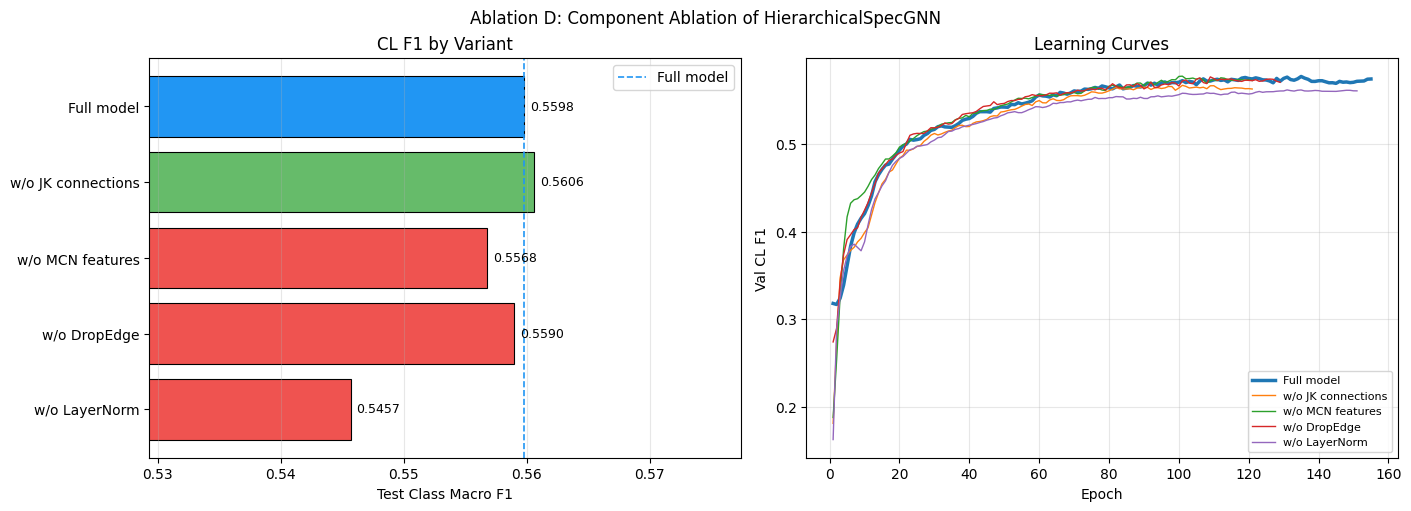

Saved: ablation_d_results.png


In [11]:
variants = list(results.keys())
cl_f1s   = [results[v]['cl_f1'] for v in variants]
full_f1  = results['Full model']['cl_f1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Ablation D: Component Ablation of HierarchicalSpecGNN', fontsize=12)

# Bar chart
ax = axes[0]
colors = ['#2196F3' if v == 'Full model' else '#EF5350' if f1 < full_f1 else '#66BB6A'
          for v, f1 in zip(variants, cl_f1s)]
bars = ax.barh(variants[::-1], cl_f1s[::-1], color=colors[::-1],
               edgecolor='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.axvline(full_f1, color='#2196F3', linestyle='--', linewidth=1.2, label='Full model')
ax.set_xlabel('Test Class Macro F1')
ax.set_title('CL F1 by Variant')
ax.set_xlim(min(cl_f1s)*0.97, max(cl_f1s)*1.03)
ax.grid(axis='x', alpha=0.3); ax.legend()

# Learning curves
ax = axes[1]
for v, m in results.items():
    lw = 2.5 if v == 'Full model' else 1.0
    ax.plot(range(1, len(m['val_cl_f1_curve'])+1), m['val_cl_f1_curve'],
            label=v, linewidth=lw)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val CL F1')
ax.set_title('Learning Curves'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, 'ablation_d_results.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_d_results.png')
